In [2]:
%run "02.1_utls.ipynb"

(5410, 36)
(4328, 34)
(1082, 34)
PotentialFraud
0    3923
1     405
Name: count, dtype: int64
PotentialFraud
0    981
1    101
Name: count, dtype: int64


In [3]:

from sklearn.metrics import accuracy_score,confusion_matrix,classification_report,roc_curve, roc_auc_score, precision_recall_curve,auc  # For model evaluation
import matplotlib.pyplot as plt  # For plotting visualizations
import xgboost as xgb  # For XGBoost classifier model


### Training XGb Regression Model

In [4]:
# Set XGBoost global configuration with verbosity level 2 for detailed output
xgb.set_config(verbosity=2)
# Get the current XGBoost configuration
config = xgb.get_config()
# Verify that verbosity is set to 2
assert config['verbosity'] == 2

# Initialize XGBoost classifier with specific hyperparameters
xgb_estimate = xgb.XGBClassifier(n_estimators= 70,  # Number of boosting rounds/trees
                                max_depth = 5,  # Maximum depth of each tree
                                min_split_loss=0.05,  # Minimum loss reduction for a split
                                learning_rate = 0.05,  # Learning rate (shrinkage/eta)]
                                random_state = 42  # Random seed for reproducibility
                                
                                )
                        
# Train the XGBoost model on the training data
xgb_estimate.fit(x_train,y_train)
# Make binary class predictions on the test set
y_pred = xgb_estimate.predict(x_test)
# Get predicted probabilities for the positive class (fraud)
y_prob = xgb_estimate.predict_proba(x_test)[:, 1]
# Print classification metrics report with precision, recall, and f1-score
print("*****Classification Rport********")
print(classification_report(y_test,y_pred))
# Print confusion matrix showing true/false positives and negatives
print("**** Confusion Matrix ***********")
print(confusion_matrix(y_test,y_pred))

[00:15:26] INFO: C:\actions-runner\_work\xgboost\xgboost\src\data\iterative_dmatrix.cc:56: Finished constructing the `IterativeDMatrix`: (4328, 34, 147152).
*****Classification Rport********
              precision    recall  f1-score   support

           0       0.96      0.99      0.97       981
           1       0.84      0.55      0.67       101

    accuracy                           0.95      1082
   macro avg       0.90      0.77      0.82      1082
weighted avg       0.94      0.95      0.94      1082

**** Confusion Matrix ***********
[[970  11]
 [ 45  56]]


In [5]:
# Calculate accuracy score on the training data
Train_score = accuracy_score(y_train,xgb_estimate.predict(x_train))
# Calculate accuracy score on the test data
Test_score = accuracy_score(y_test,y_pred)
# Print training set accuracy
print("Train_score: ", Train_score)
# Print test set accuracy
print("Test_score: ", Test_score)
# Calculate and print the overfitting percentage (difference between train and test accuracy)
print("over_fiting: ", round((Train_score - Test_score)*100,3))

Train_score:  0.9540203327171903
Test_score:  0.9482439926062847
over_fiting:  0.578


### ROC and PR Curves

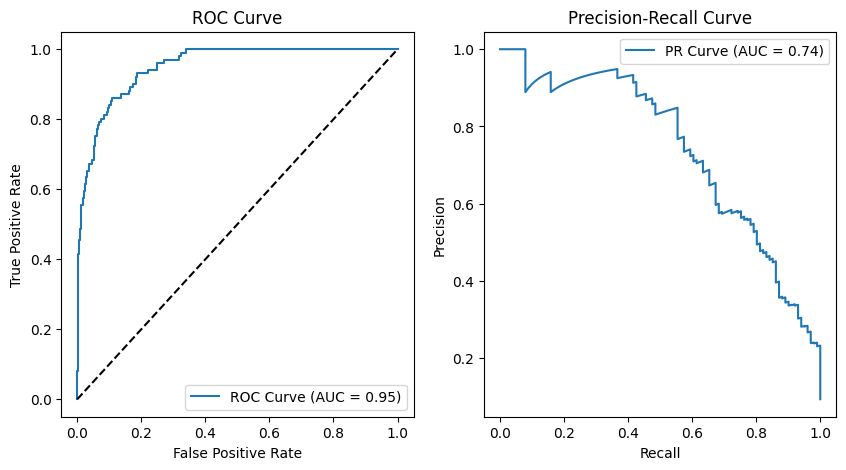

In [6]:
# Calculate false positive rate and true positive rate for ROC curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
# Calculate area under the ROC curve (AUC-ROC score)
roc_auc = auc(fpr, tpr)

# Calculate precision and recall values for Precision-Recall curve
precision, recall, _ = precision_recall_curve(y_test, y_prob)
# Calculate area under the Precision-Recall curve
pr_auc = auc(recall, precision)

# Create a figure with two subplots side by side
plt.figure(figsize=(10, 5))
# Plot ROC Curve in the first subplot
plt.subplot(1, 2, 1)
# Plot the ROC curve line with AUC score in legend
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc:.2f})')
# Plot the diagonal reference line (random classifier)
plt.plot([0, 1], [0, 1], 'k--')
# Label x-axis as False Positive Rate
plt.xlabel('False Positive Rate')
# Label y-axis as True Positive Rate
plt.ylabel('True Positive Rate')
# Set the title for ROC curve plot
plt.title('ROC Curve')
# Add legend showing the curve and AUC score
plt.legend()

# Plot Precision-Recall Curve in the second subplot
plt.subplot(1, 2, 2)
# Plot the PR curve line with AUC score in legend
plt.plot(recall, precision, label=f'PR Curve (AUC = {pr_auc:.2f})')
# Label x-axis as Recall
plt.xlabel('Recall')
# Label y-axis as Precision
plt.ylabel('Precision')
# Set the title for Precision-Recall curve plot
plt.title('Precision-Recall Curve')
# Add legend showing the curve and AUC score
plt.legend()
# Display both plots
plt.show()